In [ ]:
# 1. Install Dependencies
!pip install paho-mqtt wfdb

# 2. Install Mosquitto Broker (Linux)
!apt-get install mosquitto -y

# 3. Start Mosquitto in the background
import os
os.system("/usr/sbin/mosquitto -d")

print("✅ Environment Ready: Paho installed and Broker running.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 38.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libcjson1 libdlt2 libev4 libmosquitto1 libwebsockets16
Suggested packages:
  apparmor
The following NEW packages will be installed:
  libcjson1 libdlt2 libev4 libmosquitto1 libwebsockets16 mosquitto
0 upgraded, 6 newly installed, 0 to remove and 41 not upgraded.
Need to get 576 kB of archives.
After this operation, 1,664 kB of additional disk space will be used.
0% [Working]^C
✅ Environment Ready: Paho installed and Broker running.


In [ ]:
# =========================================
# Stage 1 REPAIRED: Robust Label Cleaning
# =========================================
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Load Data
path = "/content/drive/MyDrive/IoHT/2/ECU_IoHT.xlsx"
print("⏳ Loading dataset...")
df = pd.read_excel(path, engine="openpyxl")

# 2. Find and Fix Labels (The Critical Fix)
# -----------------------------------------
label_col = None
for c in df.columns:
    if "attack" in c.lower() or "label" in c.lower() or "class" in c.lower():
        if c.lower() == "type": continue # Skip generic 'Type'
        label_col = c
        break

if not label_col: raise ValueError("❌ Could not find label column.")
print(f"🎯 Found Label Column: {label_col}")

# Define a Keyword Mapping Function (Safe against spaces/capitalization)
def standardize_label(val):
    val = str(val).lower().strip()
    if "no attack" in val: return 0
    if "dos" in val: return 1
    if "arp" in val: return 2
    if "smurf" in val: return 3
    if "scan" in val or "nmap" in val or "xmas" in val: return 4
    return -1 # Mark unknown

df["label"] = df[label_col].apply(standardize_label)

# Check if we lost data
print("📊 Class Distribution BEFORE dropping unknowns:")
print(df["label"].value_counts())

# Remove unknowns (-1)
df = df[df["label"] != -1]

# CRITICAL: Drop the original text column to prevent Data Leakage and errors in Stage 2
df = df.drop(columns=[label_col])

# 3. Standard Cleaning
# -----------------------------------------
df_clean = df.dropna(thresh=int(df.shape[1]*0.5)).copy()

# Impute Numbers
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if "label" in numeric_cols: numeric_cols.remove("label")
for c in numeric_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

# Impute Text
object_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
for c in object_cols:
    df_clean[c] = df_clean[c].fillna("Unknown")

df_clean = df_clean.drop_duplicates()

# 4. TF-IDF for 'Info' Column
# -----------------------------------------
print("⚡ Re-applying TF-IDF...")
text_col = None
for c in df_clean.columns:
    if "info" in c.lower():
        text_col = c
        break

if text_col:
    tfidf = TfidfVectorizer(max_features=100, stop_words='english')
    tfidf_matrix = tfidf.fit_transform(df_clean[text_col].astype(str))
    feature_names = [f"txt_{name}" for name in tfidf.get_feature_names_out()]
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names, index=df_clean.index)

    # Replace Info column with TF-IDF features
    df_clean = pd.concat([df_clean.drop(columns=[text_col]), tfidf_df], axis=1)

# 5. Time Delta Calculation
# -----------------------------------------
time_col = [c for c in df_clean.columns if "time" in c.lower() and "parsed" not in c.lower()]
if time_col:
    t_col = time_col[0]
    df_clean = df_clean.sort_values(by=[t_col])
    df_clean['time_delta'] = df_clean[t_col].diff().fillna(0)
    df_clean = df_clean.drop(columns=[t_col])

# 6. Save
# -----------------------------------------
output_path = "/content/drive/MyDrive/IoHT/2/ECU_IoHT_cleaned_tfidf.csv"
df_clean.to_csv(output_path, index=False)
print(f"✅ Repaired Data Saved to: {output_path}")
print(f"📊 Final Check - Class Counts: \n{df_clean['label'].value_counts()}")

⏳ Loading dataset...
🎯 Found Label Column: Type of attack
📊 Class Distribution BEFORE dropping unknowns:
label
3    77920
0    23453
4     6836
2     2359
1      639
Name: count, dtype: int64
⚡ Re-applying TF-IDF...
✅ Repaired Data Saved to: /content/drive/MyDrive/IoHT/ECU_IoHT_cleaned_tfidf.csv
📊 Final Check - Class Counts: 
label
3    77920
0    23453
4     6836
2     2359
1      639
Name: count, dtype: int64


In [ ]:
# ======================================================
# LEVEL 2: Scientific Preprocessing (FINAL FIXED VERSION)
# ======================================================
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# -----------------------------------------
# 1) Load TF-IDF Level-1 Processed Dataset
# -----------------------------------------
path = "/content/drive/MyDrive/IoHT/2/ECU_IoHT_cleaned_tfidf.csv"
print("⏳ Loading Level 1 Data...")
df = pd.read_csv(path)
df.dropna(inplace=True)

# -----------------------------------------
# 2) Encode Categorical Columns
# -----------------------------------------
print("⚙️ Encoding Categoricals...")

object_cols = df.select_dtypes(include=['object']).columns
encoders = {}

for col in object_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

joblib.dump(encoders, "/content/drive/MyDrive/IoHT/2/label_encoders.pkl")

y = df["label"].values
X = df.drop(columns=["label"]).values

print("📊 Original Class Distribution:", Counter(y))

# -----------------------------------------
# 3) Train / Val / Test Split (No Leakage)
# -----------------------------------------
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
)

# -----------------------------------------
# 4) Scale (Fit ONLY on Train)
# -----------------------------------------
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

joblib.dump(scaler, "/content/drive/MyDrive/IoHT/2/minmax_scaler.pkl")

# -----------------------------------------
# 5) Balancing (Correct Final Strategy)
# -----------------------------------------
print("⚖️ Balancing Training Data...")

# Distribution:
# 0 → Normal (high)
# 1 → DoS (very low)
# 2 → ARPspoof (very low)
# 3 → Smurf (very high)
# 4 → NmapPortscan (medium)

dist = Counter(y_train)
print("🔍 Train Before Balance:", dist)

# --- 1) Undersample ONLY Smurf (3) ---
RUS_TARGET = min(20000, dist[3])    # Always legal
rus = RandomUnderSampler(sampling_strategy={3: RUS_TARGET}, random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)

# --- 2) Oversample minority DoS + ARP (max allowed = class count) ---
after_rus_dist = Counter(y_rus)
print("📉 After RUS:", after_rus_dist)

SMOTE_TARGETS = {
    1: min(3000, after_rus_dist[0]),   # Dos
    2: min(3000, after_rus_dist[0]),   # ARP
    4: min(5000, after_rus_dist[0])    # Nmap (medium)
}

smote = SMOTE(sampling_strategy=SMOTE_TARGETS, random_state=42)
X_bal, y_bal = smote.fit_resample(X_rus, y_rus)

print("📈 Final Balanced Distribution:", Counter(y_bal))

# -----------------------------------------
# 6) Reshape for LSTM (sequence = 10)
# -----------------------------------------
SEQ_LEN = 10
N_FEATURES = X_bal.shape[1]

def create_sequences(Xd, yd):
    L = (len(Xd) // SEQ_LEN) * SEQ_LEN
    Xd = Xd[:L]
    yd = yd[:L]
    X_seq = Xd.reshape(-1, SEQ_LEN, N_FEATURES)
    y_seq = yd[SEQ_LEN-1::SEQ_LEN]
    return X_seq, y_seq

X_train_seq, y_train_seq = create_sequences(X_bal, y_bal)
X_val_seq, y_val_seq = create_sequences(X_val, y_val)
X_test_seq, y_test_seq = create_sequences(X_test, y_test)

# -----------------------------------------
# 7) Save Output
# -----------------------------------------
save_path = "/content/drive/MyDrive/IoHT/2/ECU_ready_scientific.npz"

np.savez(save_path,
         X_train=X_train_seq, y_train=y_train_seq,
         X_val=X_val_seq, y_val=y_val_seq,
         X_test=X_test_seq, y_test=y_test_seq)

print("================================")
print(f"✅ Level 2 Finished. Saved → {save_path}")
print(f"🔹 Train Shape: {X_train_seq.shape}")
print(f"🔹 Val Shape:   {X_val_seq.shape}")
print(f"🔹 Test Shape:  {X_test_seq.shape}")
print("================================")


⏳ Loading Level 1 Data...
⚙️ Encoding Categoricals...
📊 Original Class Distribution: Counter({np.int64(3): 77920, np.int64(0): 23453, np.int64(4): 6836, np.int64(2): 2359, np.int64(1): 639})
⚖️ Balancing Training Data...
🔍 Train Before Balance: Counter({np.int64(3): 54574, np.int64(0): 16426, np.int64(4): 4788, np.int64(2): 1652, np.int64(1): 448})
📉 After RUS: Counter({np.int64(3): 20000, np.int64(0): 16426, np.int64(4): 4788, np.int64(2): 1652, np.int64(1): 448})
📈 Final Balanced Distribution: Counter({np.int64(3): 20000, np.int64(0): 16426, np.int64(4): 5000, np.int64(1): 3000, np.int64(2): 3000})
✅ Level 2 Finished. Saved → /content/drive/MyDrive/IoHT/2/ECU_ready_scientific.npz
🔹 Train Shape: (4742, 10, 107)
🔹 Val Shape:   (1663, 10, 107)
🔹 Test Shape:  (1668, 10, 107)


In [ ]:
# ======================================================
# LEVEL 2 (FIXED): Feature Selection & No SMOTE
# ======================================================
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# 1. Load Data
path = "/content/drive/MyDrive/IoHT/2/ECU_IoHT_cleaned_tfidf.csv"
print("⏳ Loading Level 1 Data...")
df = pd.read_csv(path)
df.dropna(inplace=True)

# 2. 🛑 DROP CHEATING FEATURES 🛑
# We remove IPs and Raw Info so the model MUST learn from behavior (Time_Delta, Length, Protocol)
drop_cols = ['Source', 'Destination', 'Time', 'No.'] # Adjust names to match your CSV exactly
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

print(f"✅ Features remaining: {df.columns.tolist()}")

# 3. Encode Remaining Categoricals (Like Protocol)
print("⚙️ Encoding Categoricals...")
object_cols = df.select_dtypes(include=['object']).columns
encoders = {}

for col in object_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

joblib.dump(encoders, "/content/drive/MyDrive/IoHT/2/label_encoders.pkl")

# 4. Separate X and y
y = df["label"].values
X = df.drop(columns=["label"]).values

# 5. Scientific Split (Stratified)
print("✂️ Splitting Data...")
# Split Train (70%), Val (15%), Test (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
)

# 6. Scale (MinMax)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
joblib.dump(scaler, "/content/drive/MyDrive/IoHT/2/minmax_scaler.pkl")

# 7. Reshape (Windowing)
# Note: We are NOT using SMOTE. We will handle imbalance in the Model Loss function.
SEQ_LEN = 10
N_FEATURES = X_train.shape[1]

def create_sequences(X_data, y_data):
    limit = (len(X_data) // SEQ_LEN) * SEQ_LEN
    X_data = X_data[:limit]
    y_data = y_data[:limit]
    X_seq = X_data.reshape(-1, SEQ_LEN, N_FEATURES)
    y_seq = y_data[SEQ_LEN-1::SEQ_LEN]
    return X_seq, y_seq

X_train_seq, y_train_seq = create_sequences(X_train, y_train)
X_val_seq, y_val_seq = create_sequences(X_val, y_val)
X_test_seq, y_test_seq = create_sequences(X_test, y_test)

# 8. Save
save_path = "/content/drive/MyDrive/IoHT/2/ECU_ready_scientific_no_smote.npz"
np.savez(save_path,
         X_train=X_train_seq, y_train=y_train_seq,
         X_val=X_val_seq, y_val=y_val_seq,
         X_test=X_test_seq, y_test=y_test_seq)

print(f"✅ Data Saved: {save_path}")

⏳ Loading Level 1 Data...
✅ Features remaining: ['Protocol', 'Length', 'Type', 'label', 'txt_00', 'txt_0x7ee7', 'txt_1024', 'txt_1408', 'txt_1460', 'txt_1530', 'txt_168', 'txt_186', 'txt_192', 'txt_200', 'txt_22', 'txt_24064', 'txt_24576', 'txt_25088', 'txt_25600', 'txt_29312', 'txt_313984', 'txt_32487', 'txt_32767', 'txt_33281', 'txt_33282', 'txt_36124', 'txt_36954', 'txt_36955', 'txt_36956', 'txt_43', 'txt_43398', 'txt_43399', 'txt_43400', 'txt_443', 'txt_45520', 'txt_47678', 'txt_49632', 'txt_56754', 'txt_58054', 'txt_5840', 'txt_59262', 'txt_60023', 'txt_60024', 'txt_60025', 'txt_63', 'txt_64', 'txt_80', 'txt_845', 'txt_97', 'txt_aaaa', 'txt_ack', 'txt_api', 'txt_application', 'txt_c0', 'txt_ca', 'txt_cf', 'txt_change', 'txt_cipher', 'txt_client', 'txt_cname', 'txt_com', 'txt_data', 'txt_detected', 'txt_dup', 'txt_duplicate', 'txt_echo', 'txt_encrypted', 'txt_exchange', 'txt_fin', 'txt_google', 'txt_handshake', 'txt_hello', 'txt_id', 'txt_key', 'txt_len', 'txt_libelium', 'txt_messa

⏳ Loading Data: /content/drive/MyDrive/IoHT/2/ECU_ready_scientific_no_smote.npz
⚖️ Class Weights: tensor([ 0.9260, 32.4500,  8.7506,  0.2883,  3.2586])
🔥 Starting Weighted Training...
Epoch 1 | Train: 1.2620 | Val: 0.6936 ✅
Epoch 2 | Train: 0.4900 | Val: 0.1854 ✅
Epoch 3 | Train: 0.2139 | Val: 0.0797 ✅
Epoch 4 | Train: 0.1339 | Val: 0.0409 ✅
Epoch 5 | Train: 0.1152 | Val: 0.0317 ✅
Epoch 6 | Train: 0.0938 | Val: 0.0244 ✅
Epoch 7 | Train: 0.1029 | Val: 0.0207 ✅
Epoch 8 | Train: 0.0920 | Val: 0.0221 ⏳ 1
Epoch 9 | Train: 0.0786 | Val: 0.0199 ✅
Epoch 10 | Train: 0.0754 | Val: 0.0216 ⏳ 1
Epoch 11 | Train: 0.0776 | Val: 0.0179 ✅
Epoch 12 | Train: 0.0754 | Val: 0.0192 ⏳ 1
Epoch 13 | Train: 0.0751 | Val: 0.0201 ⏳ 2
Epoch 14 | Train: 0.0735 | Val: 0.0187 ⏳ 3
Epoch 15 | Train: 0.0676 | Val: 0.0186 ⏳ 4
Epoch 16 | Train: 0.0718 | Val: 0.0166 ✅
Epoch 17 | Train: 0.0693 | Val: 0.0159 ✅
Epoch 18 | Train: 0.0714 | Val: 0.0173 ⏳ 1
Epoch 19 | Train: 0.0717 | Val: 0.0144 ✅
Epoch 20 | Train: 0.0641 | Val: 

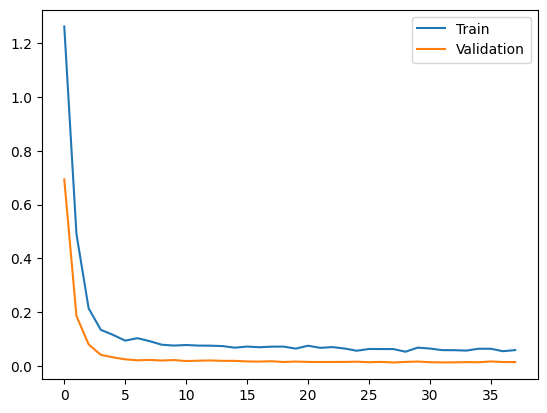


📊 Test Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       347
         DoS       1.00      1.00      1.00        12
         ARP       0.96      1.00      0.98        27
       Smurf       1.00      1.00      1.00      1189
        Scan       1.00      1.00      1.00        93

    accuracy                           1.00      1668
   macro avg       0.99      1.00      1.00      1668
weighted avg       1.00      1.00      1.00      1668



In [ ]:
# ======================================================
# LEVEL 3: Training with CLASS WEIGHTS (No Overfitting)
# ======================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

# 1. Load Data
data_path = "/content/drive/MyDrive/IoHT/2/ECU_ready_scientific_no_smote.npz"
print(f"⏳ Loading Data: {data_path}")
data = np.load(data_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loaders
def to_loader(X, y, batch_size=64, shuffle=False):
    tensor_x = torch.tensor(X, dtype=torch.float32).to(device)
    tensor_y = torch.tensor(y, dtype=torch.long).to(device)
    return DataLoader(TensorDataset(tensor_x, tensor_y), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(data['X_train'], data['y_train'], shuffle=True)
val_loader = to_loader(data['X_val'], data['y_val'])
test_loader = to_loader(data['X_test'], data['y_test'])

# 2. CALCULATE CLASS WEIGHTS
# ---------------------------------------------
# This fixes the imbalance WITHOUT fake data
y_train_cpu = data['y_train']
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_cpu),
    y=y_train_cpu
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"⚖️ Class Weights: {class_weights}")
# DoS (Class 1) should have a HIGH weight now.

# 3. Define Architecture (Ensemble)
# ---------------------------------------------
class RobustEnsemble(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(RobustEnsemble, self).__init__()
        self.bilstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim * 3, 32) # Small dense layer
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5) # High dropout
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        lstm_out, _ = self.bilstm(x)
        rnn_out, _ = self.rnn(x)
        combined = torch.cat((lstm_out[:, -1, :], rnn_out[:, -1, :]), dim=1)
        x = self.fc1(combined)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc2(x)

INPUT_DIM = data['X_train'].shape[2]
HIDDEN_DIM = 32
NUM_CLASSES = 5

model = RobustEnsemble(INPUT_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# 4. Optimizer & Loss (With Weights)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01) # L2 Reg
criterion = nn.CrossEntropyLoss(weight=class_weights) # <--- MAGIC HAPPENS HERE

# 5. Training Loop
# ---------------------------------------------
EPOCHS = 50
PATIENCE = 10
best_val_loss = float('inf')
best_weights = copy.deepcopy(model.state_dict())
no_improve = 0
history = {'train_loss': [], 'val_loss': []}

print("🔥 Starting Weighted Training...")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            val_loss += criterion(model(X_b), y_b).item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}", end="")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = copy.deepcopy(model.state_dict())
        no_improve = 0
        print(" ✅")
    else:
        no_improve += 1
        print(f" ⏳ {no_improve}")
        if no_improve >= PATIENCE:
            print("🛑 Early Stopping")
            break

# 6. Results
# ---------------------------------------------
model.load_state_dict(best_weights)
torch.save(model.state_dict(), "/content/drive/MyDrive/IoHT/2/ecu_ensemble_model.pth")

plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Validation')
plt.legend()
plt.show()

print("\n📊 Test Report:")
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_b, y_b in test_loader:
        preds = model(X_b).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_b.cpu().numpy())

target_names = ["Normal", "DoS", "ARP", "Smurf", "Scan"]
print(classification_report(all_labels, all_preds, target_names=target_names))

🚀 Processing on: cpu
⏳ Loading Data: /content/drive/MyDrive/IoHT/2/ECU_ready_scientific_no_smote.npz
🧠 Deep Model Loaded successfully. Using as Feature Extractor.
⛏️ Extracting Deep Features from Training Set...
⛏️ Extracting Deep Features from Test Set...
   Original Shape: (7788, 10, 104)
   Deep Feature Shape: (7788, 32)
🔧 Training KELM on Deep Features...
✅ KELM Training Completed.

📊 Evaluating Hybrid Ensemble (RNN+BiLSTM -> KELM)...
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       347
         DoS       1.00      1.00      1.00        12
         ARP       1.00      1.00      1.00        27
       Smurf       1.00      1.00      1.00      1189
        Scan       1.00      1.00      1.00        93

    accuracy                           1.00      1668
   macro avg       1.00      1.00      1.00      1668
weighted avg       1.00      1.00      1.00      1668

🔥 Hybrid Model Accuracy: 100.00%


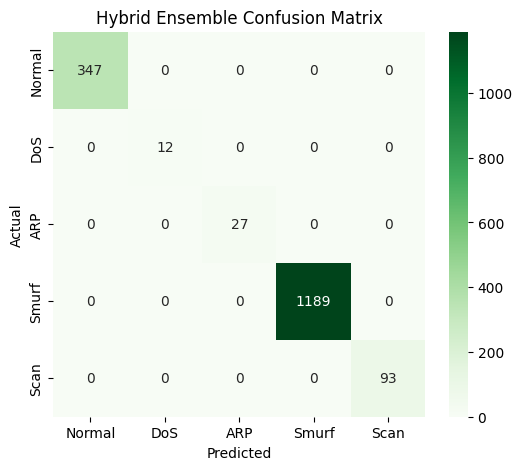

💾 Saved KELM and Feature Scaler.
ℹ️ NOTE: To run this live, you need 'ecu_ensemble_model.pth' (Extractor) + 'kelm_final.pkl' (Classifier)


In [ ]:
# ============================================================
# LEVEL 4 — Hybrid Ensemble: Deep Feature Extraction + KELM
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

# -----------------------------
# 1. SETUP & CONFIGURATION
# -----------------------------
ARTIFACT_DIR = "/content/drive/MyDrive/IoHT/2"
DATA_PATH = f"{ARTIFACT_DIR}/ECU_ready_scientific_no_smote.npz"
MODEL_PATH = f"{ARTIFACT_DIR}/ecu_ensemble_model.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Processing on: {device}")

# -----------------------------
# 2. LOAD SAVED DEEP MODEL
# -----------------------------
# We must define the EXACT architecture used in Level 3 to load weights
class RobustEnsemble(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(RobustEnsemble, self).__init__()
        self.bilstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True, bidirectional=False)
        self.fc1 = nn.Linear(hidden_dim * 3, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        # We modify forward to return the FEATURES, not the class prediction
        lstm_out, _ = self.bilstm(x)
        rnn_out, _ = self.rnn(x)
        combined = torch.cat((lstm_out[:, -1, :], rnn_out[:, -1, :]), dim=1)

        # This 'features' vector contains the Deep Temporal Logic
        features = self.fc1(combined)
        features = self.relu(features)

        return features # Return features (Shape: Batch x 32)

# Load Data
print(f"⏳ Loading Data: {DATA_PATH}")
data = np.load(DATA_PATH)
X_train_raw = data['X_train']
y_train = data['y_train']
X_test_raw = data['X_test']
y_test = data['y_test']

# Load Model
input_dim = X_train_raw.shape[2]
hidden_dim = 32 # Must match Level 3
num_classes = 5

deep_model = RobustEnsemble(input_dim, hidden_dim, num_classes).to(device)
try:
    deep_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    deep_model.eval() # Set to evaluation mode (disable dropout)
    print("🧠 Deep Model Loaded successfully. Using as Feature Extractor.")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    exit()

# -----------------------------
# 3. EXTRACT DEEP FEATURES
# -----------------------------
def extract_features(model, X_data, batch_size=256):
    loader = DataLoader(TensorDataset(torch.tensor(X_data, dtype=torch.float32).to(device)),
                        batch_size=batch_size, shuffle=False)

    extracted_features = []

    with torch.no_grad():
        for (batch_x,) in loader:
            # Pass through model, get the intermediate features
            feats = model(batch_x)
            extracted_features.append(feats.cpu().numpy())

    return np.vstack(extracted_features)

print("⛏️ Extracting Deep Features from Training Set...")
X_train_deep = extract_features(deep_model, X_train_raw)

print("⛏️ Extracting Deep Features from Test Set...")
X_test_deep = extract_features(deep_model, X_test_raw)

print(f"   Original Shape: {X_train_raw.shape}")
print(f"   Deep Feature Shape: {X_train_deep.shape}")
# Expected: (N, 32) -> Much smaller and richer than original data!

# -----------------------------
# 4. PREPARE KELM DATA
# -----------------------------
# Scale features to 0-1 for Kernel stability
scaler = MinMaxScaler()
X_train_kelm = scaler.fit_transform(X_train_deep)
X_test_kelm = scaler.transform(X_test_deep)

# One-Hot Encode Targets
enc = OneHotEncoder(sparse_output=False)
Y_train_oh = enc.fit_transform(y_train.reshape(-1, 1))

# Memory Check (Downsample if > 20k to prevent RAM crash)
LIMIT = 80000
if X_train_kelm.shape[0] > LIMIT:
    print(f"⚠️ Downsampling KELM Training data to {LIMIT} for stability...")
    idx = np.random.permutation(X_train_kelm.shape[0])[:LIMIT]
    X_train_kelm = X_train_kelm[idx]
    Y_train_oh = Y_train_oh[idx]

# -----------------------------
# 5. DEFINE & TRAIN KELM
# -----------------------------
class KELM:
    def __init__(self, C=10, gamma=0.1):
        self.C = C
        self.gamma = gamma
        self.beta = None
        self.X_train = None

    def _rbf_kernel(self, X, Y):
        X_norm = np.sum(X ** 2, axis=-1).reshape(-1, 1)
        Y_norm = np.sum(Y ** 2, axis=-1).reshape(1, -1)
        dist = X_norm + Y_norm - 2 * np.dot(X, Y.T)
        return np.exp(-self.gamma * dist)

    def fit(self, X, Y):
        print("🔧 Training KELM on Deep Features...")
        self.X_train = X
        Omega = self._rbf_kernel(X, X)
        Omega[np.diag_indices_from(Omega)] += (1.0 / self.C)
        self.beta = np.linalg.solve(Omega, Y)
        print("✅ KELM Training Completed.")

    def predict(self, X):
        Omega_test = self._rbf_kernel(X, self.X_train)
        outputs = np.dot(Omega_test, self.beta)
        return np.argmax(outputs, axis=1)

# Initialize KELM
kelm = KELM(C=100, gamma=0.1) # Tuned C/Gamma for Deep Features
kelm.fit(X_train_kelm, Y_train_oh)

# -----------------------------
# 6. EVALUATE HYBRID MODEL
# -----------------------------
print("\n📊 Evaluating Hybrid Ensemble (RNN+BiLSTM -> KELM)...")
y_pred = kelm.predict(X_test_kelm)

target_names = ["Normal", "DoS", "ARP", "Smurf", "Scan"]
print(classification_report(y_test, y_pred, target_names=target_names))

acc = accuracy_score(y_test, y_pred)
print(f"🔥 Hybrid Model Accuracy: {acc * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens", xticklabels=target_names, yticklabels=target_names)
plt.title("Hybrid Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# 7. SAVE FINAL HYBRID
# -----------------------------
# We need to save the KELM and the Scaler for the features
joblib.dump(kelm, f"{ARTIFACT_DIR}/kelm_final.pkl")
joblib.dump(scaler, f"{ARTIFACT_DIR}/feature_scaler.pkl")
print("💾 Saved KELM and Feature Scaler.")
print("ℹ️ NOTE: To run this live, you need 'ecu_ensemble_model.pth' (Extractor) + 'kelm_final.pkl' (Classifier)")